### House Price Prediction using Machine Learning in Python

# Objective
The objective of this project is to build a machine learning model to predict house prices based on features such as house size, number of bedrooms, floor details, and nearby facilities. Different machine learning algorithms are used to analyze the data and improve prediction accuracy.

# Dataset
The dataset used in this project is the Indian House Price Data dataset, which contains around 999 records and 23 features related to housing properties such as BHK, size in square feet, year built, floor number, nearby schools, nearby hospitals, and price in lakhs.

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
# Load the dataset

data = pd.read_csv("Indian House Price Data .csv")

# Display first 5 rows
data.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [4]:
# Display dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              999 non-null    int64  
 1   State                           999 non-null    object 
 2   City                            999 non-null    object 
 3   Locality                        999 non-null    object 
 4   Property_Type                   999 non-null    object 
 5   BHK                             999 non-null    int64  
 6   Size_in_SqFt                    999 non-null    int64  
 7   Price_in_Lakhs                  999 non-null    float64
 8   Price_per_SqFt                  999 non-null    float64
 9   Year_Built                      999 non-null    int64  
 10  Furnished_Status                999 non-null    object 
 11  Floor_No                        999 non-null    int64  
 12  Total_Floors                    999 

In [5]:
# Statistical summary
data.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.000000
mean,500.000000,2.914915,2739.569570,257.066687,0.131752,2006.709710,14.766767,15.428428,18.290290,5.462462,5.391391
std,288.530761,1.426828,1306.529168,141.533299,0.130940,9.921931,8.995137,8.738613,9.921931,2.877308,2.889752
min,1.000000,1.000000,502.000000,11.590000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,250.500000,2.000000,1617.500000,134.655000,0.050000,1998.000000,7.000000,8.000000,9.500000,3.000000,3.000000
50%,500.000000,3.000000,2639.000000,261.840000,0.100000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,749.500000,4.000000,3886.500000,381.735000,0.160000,2015.500000,23.000000,23.000000,27.000000,8.000000,8.000000
max,999.000000,5.000000,5000.000000,499.570000,0.970000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


In [6]:
# Check missing values
data.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [7]:
# Check data types of each column
data.dtypes

ID                                  int64
State                              object
City                               object
Locality                           object
Property_Type                      object
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                   object
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility     object
Parking_Space                      object
Security                           object
Amenities                          object
Facing                             object
Owner_Type                         object
Availability_Status                object
dtype: object

In [8]:
# Fill missing values with median for numerical columns
data = data.fillna(data.median(numeric_only=True))

# Drop unnecessary columns if any
data = data.drop(columns=['Property_ID'], errors='ignore')

# Check again for missing values
data.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

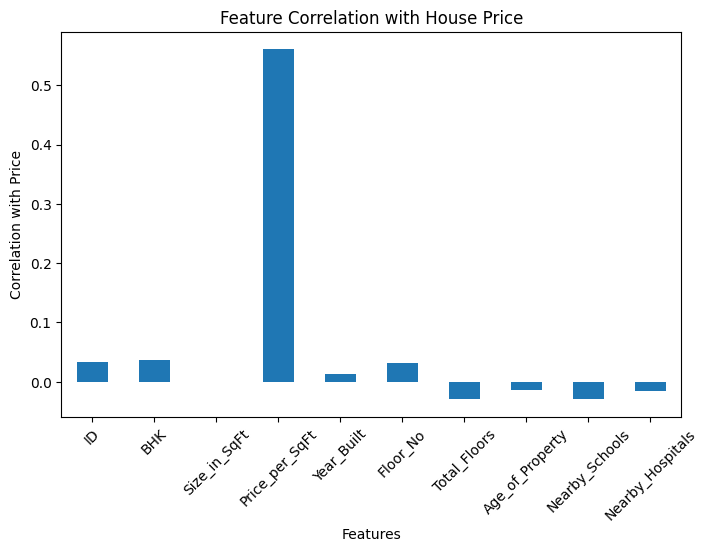

In [12]:
# Calculate correlation with price
corr = data.corr(numeric_only=True)['Price_in_Lakhs'].drop('Price_in_Lakhs')

# Plot bar graph
plt.figure(figsize=(8,5))
corr.plot(kind='bar')

plt.title("Feature Correlation with House Price")
plt.xlabel("Features")
plt.ylabel("Correlation with Price")
plt.xticks(rotation=45)

plt.show()

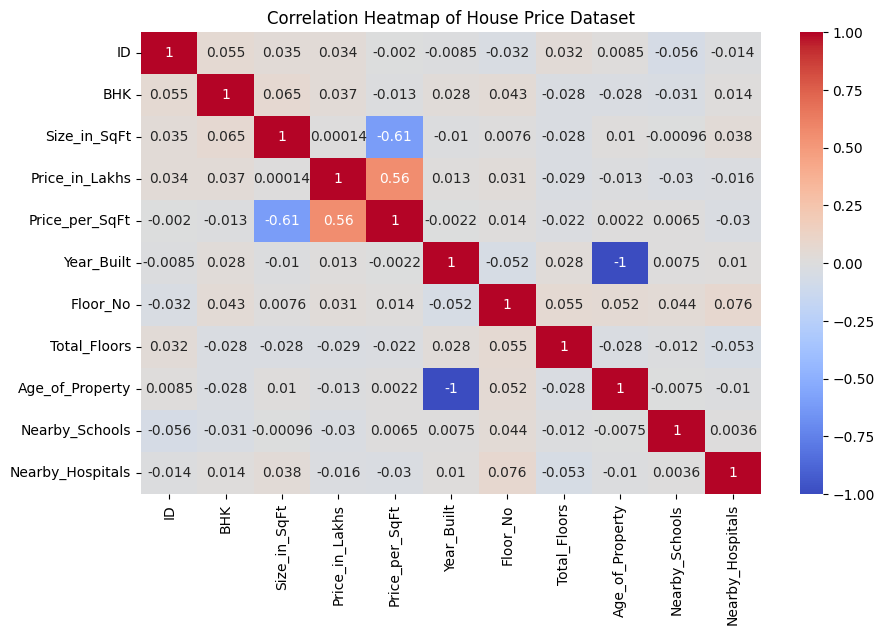

In [15]:
# Correlation Heatmap
plt.figure(figsize=(10,6))

sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap of House Price Dataset")

plt.show()

In [13]:
# Select important features
X = data[['BHK','Size_in_SqFt','Year_Built','Floor_No','Total_Floors',
          'Nearby_Schools','Nearby_Hospitals']]

# Target variable
y = data['Price_in_Lakhs']

print(X.head())

   BHK  Size_in_SqFt  Year_Built  Floor_No  Total_Floors  Nearby_Schools  \
0    1          4740        1990        22             1              10   
1    3          2364        2008        21            20               8   
2    2          3642        1997        19            27               9   
3    2          2741        1991        21            26               5   
4    4          4823        2002         3             2               4   

   Nearby_Hospitals  
0                 3  
1                 1  
2                 8  
3                 7  
4                 9  


In [14]:
# Splitting Dataset into Training and Testing Data
from sklearn.model_selection import train_test_split

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (799, 7)
Testing data size: (200, 7)


In [17]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

In [19]:
# Training and Evaluating Models

# Create models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVM": SVR(kernel='rbf')
}

# Train and evaluate models
results = {}

for name, model in models.items():
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    predictions = model.predict(X_test_scaled)
    
    # Evaluate model
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    results[name] = r2
    
    print("Model:", name)
    print("Mean Absolute Error:", mae)
    print("R2 Score:", r2)
    print("-----------------------")

Model: Linear Regression
Mean Absolute Error: 126.989570060259
R2 Score: -0.012131568117779601
-----------------------
Model: Random Forest
Mean Absolute Error: 129.3790325
R2 Score: -0.07882665175839443
-----------------------
Model: SVM
Mean Absolute Error: 126.53794050667356
R2 Score: -0.001033576135733405
-----------------------


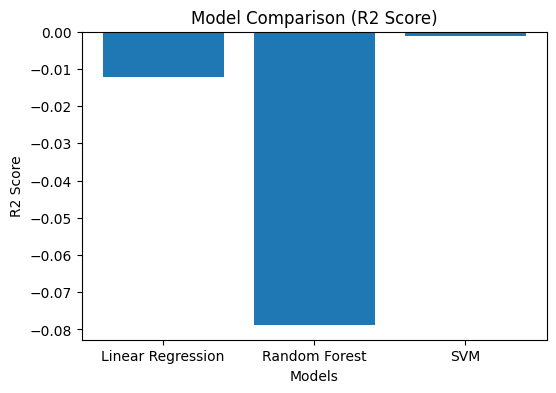

In [20]:
# Model Comparison Graph
# Plot model comparison
plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values())
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

In [23]:
# Predicting House Price for New Data
# Create new house data with column names
new_house = pd.DataFrame([[3, 1500, 2015, 2, 5, 3, 2]],
 columns=['BHK','Size_in_SqFt','Year_Built','Floor_No','Total_Floors','Nearby_Schools','Nearby_Hospitals'])

# Scale the input
new_house_scaled = scaler.transform(new_house)

# Predict price
predicted_price = best_model.predict(new_house_scaled)

print("Predicted House Price (in Lakhs):", predicted_price[0])

Predicted House Price (in Lakhs): 263.84141567877447
